# 🔬 Comparaison Modèles RAG & LLM — VITAL-AGENT (Multi-Provider v2)

### 🏗️ Architecture testée
- **Partie 1** : Retrieval — BM25 vs TF-IDF vs Bag-of-Words
- **Partie 2** : Fusion — RRF vs Score Moyen vs Score Max
- **Partie 3** : LLM — Groq (4 clés) + OpenRouter (`:free`) — modèles **100% actifs en avril 2026**

### 🔑 Stratégie
- **Groq** : uniquement les modèles en production / preview actifs (pas de décommissionnés)
- **OpenRouter** : modèles `:free` confirmés actifs (Llama 3.3 70b, DeepSeek R1, Gemma 3, Qwen 2.5 72b…)
- **Gemini** : retiré (quota dépassé sur les 3 clés fournies)
- Modèles en erreur → **exclus automatiquement** du tableau final
- Chaque graphe Partie 3 est **séparé et agrandi**


In [24]:
import subprocess, sys
packages = ["pandas","numpy","scikit-learn","openpyxl","requests","matplotlib","seaborn","tabulate"]
for pkg in packages:
    subprocess.check_call([sys.executable,"-m","pip","install",pkg,"-q","--break-system-packages"],stderr=subprocess.DEVNULL)
print("✅ Dépendances installées")


✅ Dépendances installées


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import time, math, re, requests, warnings
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tabulate import tabulate

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print(f"✅ Imports OK — pandas {pd.__version__} | numpy {np.__version__}")


✅ Imports OK — pandas 2.3.3 | numpy 2.0.2


## 🔑 Cellule 3 — Configuration Groq + OpenRouter (modèles actifs avril 2026)

In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# 🔑  GROQ — 4 clés  |  Modèles PRODUCTION & PREVIEW actifs en avril 2026
#     Source : https://console.groq.com/docs/models
# ══════════════════════════════════════════════════════════════════════════════
GROQ_KEYS = [
    "",  # G1
    "",  # G2
    "f",  # G3
    "l",  # G4
]

# ══════════════════════════════════════════════════════════════════════════════
# 🔑  OPENROUTER — 1 clé  |  Modèles :free actifs
#     Source : https://openrouter.ai/collections/free-models
# ══════════════════════════════════════════════════════════════════════════════
OPENROUTER_KEY = ""

DATA_PATH = "/kaggle/input/datasets/ammarbedis/vital-data/NEW_vital_data_enriched_UPDATED.xlsx"

# ══════════════════════════════════════════════════════════════════════════════
# 🤖  CATALOGUE — GROQ (production + preview, confirmés actifs)
#     Rotation sur les 4 clés pour éviter les rate limits
# ══════════════════════════════════════════════════════════════════════════════
GROQ_MODELS = [
    # Clé G1 — Production
    {"label": "Llama 3.1 8b",           "model": "llama-3.1-8b-instant",                          "key_index": 0, "provider": "groq"},
    {"label": "Llama 3.3 70b",          "model": "llama-3.3-70b-versatile",                       "key_index": 0, "provider": "groq"},
    # Clé G2 — Preview Llama 4
    {"label": "Llama 4 Scout 17b",      "model": "meta-llama/llama-4-scout-17b-16e-instruct",     "key_index": 1, "provider": "groq"},
    {"label": "GPT-OSS 20b",            "model": "openai/gpt-oss-20b",                            "key_index": 1, "provider": "groq"},
    # Clé G3 — Preview reasoning
    {"label": "Qwen3 32b",              "model": "qwen/qwen-3-32b",                               "key_index": 2, "provider": "groq"},
    {"label": "GPT-OSS 120b",           "model": "openai/gpt-oss-120b",                           "key_index": 2, "provider": "groq"},
    # Clé G4 — Preview Kimi
    {"label": "Kimi K2 0905",           "model": "moonshotai/kimi-k2-instruct-0905",              "key_index": 3, "provider": "groq"},
    {"label": "Llama 3.1 8b [G4]",      "model": "llama-3.1-8b-instant",                          "key_index": 3, "provider": "groq"},
]

# ══════════════════════════════════════════════════════════════════════════════
# 🤖  CATALOGUE — OPENROUTER :free (confirmés actifs avril 2026)
# ══════════════════════════════════════════════════════════════════════════════
OPENROUTER_MODELS = [
    {"label": "Llama 3.3 70b (OR)",    "model": "meta-llama/llama-3.3-70b-instruct:free",        "key_index": 0, "provider": "openrouter"},
    {"label": "DeepSeek R1 (OR)",      "model": "deepseek/deepseek-r1:free",                      "key_index": 0, "provider": "openrouter"},
    {"label": "Gemma 3 12b (OR)",      "model": "google/gemma-3-12b-it:free",                     "key_index": 0, "provider": "openrouter"},
    {"label": "Qwen 2.5 72b (OR)",     "model": "qwen/qwen-2.5-72b-instruct:free",               "key_index": 0, "provider": "openrouter"},
    {"label": "Trinity Large (OR)",    "model": "arcee-ai/trinity-large-preview:free",            "key_index": 0, "provider": "openrouter"},
]

ALL_MODELS = GROQ_MODELS + OPENROUTER_MODELS

print("✅ Configuration OK — Modèles actifs avril 2026")
print(f"   Groq      : {len(GROQ_MODELS)} modèles sur 4 clés")
print(f"   OpenRouter: {len(OPENROUTER_MODELS)} modèles :free")
print(f"   Total     : {len(ALL_MODELS)} modèles à tester")
for m in ALL_MODELS:
    print(f"   [{m['provider'].upper():<11}] {m['label']:<25} → {m['model']}")


✅ Configuration OK — Modèles actifs avril 2026
   Groq      : 8 modèles sur 4 clés
   OpenRouter: 5 modèles :free
   Total     : 13 modèles à tester
   [GROQ       ] Llama 3.1 8b              → llama-3.1-8b-instant
   [GROQ       ] Llama 3.3 70b             → llama-3.3-70b-versatile
   [GROQ       ] Llama 4 Scout 17b         → meta-llama/llama-4-scout-17b-16e-instruct
   [GROQ       ] GPT-OSS 20b               → openai/gpt-oss-20b
   [GROQ       ] Qwen3 32b                 → qwen/qwen-3-32b
   [GROQ       ] GPT-OSS 120b              → openai/gpt-oss-120b
   [GROQ       ] Kimi K2 0905              → moonshotai/kimi-k2-instruct-0905
   [GROQ       ] Llama 3.1 8b [G4]         → llama-3.1-8b-instant
   [OPENROUTER ] Llama 3.3 70b (OR)        → meta-llama/llama-3.3-70b-instruct:free
   [OPENROUTER ] DeepSeek R1 (OR)          → deepseek/deepseek-r1:free
   [OPENROUTER ] Gemma 3 12b (OR)          → google/gemma-3-12b-it:free
   [OPENROUTER ] Qwen 2.5 72b (OR)         → qwen/qwen-2.5-72b-instr

## 📂 Cellule 4 — Chargement des données VITAL

In [27]:
df = pd.read_excel(DATA_PATH)

str_cols = ['product_class','stock_status','competitor_density','substitution_risk',
            'global_category_trend','lifecycle_stage_predicted','promo_frequency',
            'gamme','form','therapeutic_theme','product_name']
for col in str_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

df['stock_status']          = df['stock_status'].str.lower()
df['competitor_density']    = df['competitor_density'].str.lower()
df['substitution_risk']     = df['substitution_risk'].str.lower()
df['global_category_trend'] = df['global_category_trend'].str.lower()

print(f"✅ Dataset chargé : {len(df)} produits × {len(df.columns)} colonnes")
df[['product_name','gamme','lifecycle_stage_predicted','price','rating']].head(5)


✅ Dataset chargé : 511 produits × 24 colonnes


,product_name,gamme,lifecycle_stage_predicted,price,rating
0,Aide minceur,Autres,Croissance,24.900,4.0
1,Aktiv Vital Arteres 90 Gélules,Aktiv Vital,Croissance,34.159,2.7
2,AKTIV VITAL YEUX 30 COMPRIMES,Aktiv Vital,Croissance,33.234,4.5
3,Aktiv Vital Yeux 30 Gélules,Aktiv Vital,Croissance,39.632,4.9
4,AKTIV VITAL YEUX+OMEGA 3 30...,Aktiv Vital,Croissance,47.877,4.5


In [28]:
def build_passage(row) -> str:
    parts = [
        f"PRODUIT: {row.get('product_name', '')}",
        f"GAMME: {row.get('gamme', '')}  |  CLASSE: {row.get('product_class', '')}",
        f"THÈME THÉRAPEUTIQUE: {row.get('therapeutic_theme', '')}",
        f"FORME: {row.get('form', '')}",
        f"PRIX: {row.get('price', '')} TND  |  PRIX PROMO: {row.get('promo_price', '')} TND",
        f"NOTE: {row.get('rating', '')} / 5  |  AVIS: {row.get('review_count', '')} reviews",
        f"STOCK: {row.get('stock_status', '')}",
        f"TENDANCE MARCHÉ: {row.get('global_category_trend', '')}",
        f"DENSITÉ CONCURRENTIELLE: {row.get('competitor_density', '')}",
        f"CYCLE DE VIE: {row.get('lifecycle_stage_predicted', '')}",
        f"INDICATIONS: {str(row.get('indications', ''))[:350]}",
        f"COMPOSITION: {str(row.get('composition', ''))[:300]}",
    ]
    return '\n'.join([p for p in parts
                      if p.split(': ', 1)[-1].strip() not in ['', 'nan', 'None']])

df['passage'] = df.apply(build_passage, axis=1)
passages = df['passage'].tolist()
print(f"✅ {len(passages)} passages construits")
print(passages[0])


✅ 511 passages construits
PRODUIT: Aide minceur
GAMME: Autres  |  CLASSE: Complément alimentaire
THÈME THÉRAPEUTIQUE: Digestif
FORME: Gélule
PRIX: 24.9 TND  |  PRIX PROMO: 20.19 TND
NOTE: 4.0 / 5  |  AVIS: 2 reviews
STOCK: rupture ponctuelle
TENDANCE MARCHÉ: plateau
DENSITÉ CONCURRENTIELLE: forte
CYCLE DE VIE: Croissance
INDICATIONS: – Coupe faim
– Piège les sucres et les graisses
– Facilite la digestion
COMPOSITION: Agar agar


## 🔍 PARTIE 1 — Comparaison des modèles de RETRIEVAL
BM25 Projet vs BM25 Variante vs TF-IDF Projet vs TF-IDF Simple vs Bag-of-Words

In [29]:
class BM25:
    def __init__(self, corpus, k1=1.5, b=0.75):
        self.k1 = k1; self.b = b
        self.tokenize = lambda text: re.findall(r'\w+', text.lower())
        tokenized  = [self.tokenize(doc) for doc in corpus]
        self.N     = len(tokenized)
        self.avgdl = sum(len(d) for d in tokenized) / max(self.N, 1)
        self.tf = []
        for doc in tokenized:
            freq = {}
            for token in doc: freq[token] = freq.get(token, 0) + 1
            self.tf.append(freq)
        df_count = {}
        for freq in self.tf:
            for token in freq: df_count[token] = df_count.get(token, 0) + 1
        self.idf = {token: math.log((self.N - df + 0.5) / (df + 0.5) + 1)
                    for token, df in df_count.items()}

    def score(self, query, top_k=10):
        tokens = self.tokenize(query)
        scores = np.zeros(self.N)
        for token in tokens:
            if token not in self.idf: continue
            idf = self.idf[token]
            for i, freq in enumerate(self.tf):
                tf = freq.get(token, 0)
                dl = sum(freq.values())
                scores[i] += idf * (tf*(self.k1+1)) / (tf + self.k1*(1 - self.b + self.b*dl/self.avgdl))
        top_idx = np.argsort(scores)[::-1][:top_k]
        return top_idx, scores[top_idx]

class BM25_Variant:
    def __init__(self, corpus, k1=1.2, b=0.5):
        self._bm25 = BM25(corpus, k1=k1, b=b)
    def score(self, query, top_k=10):
        return self._bm25.score(query, top_k)

print("✅ Classes BM25 définies")


✅ Classes BM25 définies


In [30]:
print("⏳ Construction des index...")

t0 = time.time(); bm25_project = BM25(passages, k1=1.5, b=0.75)
print(f"  ✅ BM25 Projet (k1=1.5, b=0.75) — {time.time()-t0:.2f}s")

t0 = time.time(); bm25_variant = BM25_Variant(passages, k1=1.2, b=0.5)
print(f"  ✅ BM25 Variante (k1=1.2, b=0.5) — {time.time()-t0:.2f}s")

t0 = time.time()
tfidf_project = TfidfVectorizer(analyzer='word', ngram_range=(1,3), min_df=1, max_features=25000, sublinear_tf=True)
tfidf_matrix_project = tfidf_project.fit_transform(passages)
print(f"  ✅ TF-IDF Projet (1-3 ngram, 25k feat) — {time.time()-t0:.2f}s | vocab: {len(tfidf_project.vocabulary_):,}")

t0 = time.time()
tfidf_simple = TfidfVectorizer(analyzer='word', ngram_range=(1,2), min_df=1, max_features=10000, sublinear_tf=False)
tfidf_matrix_simple = tfidf_simple.fit_transform(passages)
print(f"  ✅ TF-IDF Simple (1-2 ngram, 10k feat) — {time.time()-t0:.2f}s")

t0 = time.time()
bow_vectorizer = CountVectorizer(analyzer='word', ngram_range=(1,1), max_features=10000)
bow_matrix = bow_vectorizer.fit_transform(passages)
print(f"  ✅ Bag-of-Words (1-gram, 10k feat) — {time.time()-t0:.2f}s")


⏳ Construction des index...
  ✅ BM25 Projet (k1=1.5, b=0.75) — 0.02s
  ✅ BM25 Variante (k1=1.2, b=0.5) — 0.02s
  ✅ TF-IDF Projet (1-3 ngram, 25k feat) — 0.09s | vocab: 16,721
  ✅ TF-IDF Simple (1-2 ngram, 10k feat) — 0.06s
  ✅ Bag-of-Words (1-gram, 10k feat) — 0.03s


In [31]:
TEST_QUERIES = [
    ("Aktiv Vital Arteres",               ["Aktiv Vital Arteres 90 Gélules"],    "Recherche exacte"),
    ("complément alimentaire circulation", ["Aktiv Vital Arteres 90 Gélules"],    "Thème clinique"),
    ("produit minceur gélule",            ["Aide minceur"],                       "Minceur + forme"),
    ("omega 3 yeux",                      ["AKTIV VITAL YEUX+OMEGA 3 30..."],     "Multi-termes"),
    ("ferbiotic",                         ["Ferbiotic"],                          "Recherche gamme"),
]

def precision_at_k(retrieved, relevant, k=5):
    hits = sum(1 for r in retrieved[:k] if any(rel.lower() in r.lower() or r.lower() in rel.lower() for rel in relevant))
    return hits / k

def recall_at_k(retrieved, relevant, k=5):
    if not relevant: return 0.0
    hits = sum(1 for rel in relevant if any(rel.lower() in r.lower() or r.lower() in rel.lower() for r in retrieved[:k]))
    return hits / len(relevant)

def mrr(retrieved, relevant):
    for rank, name in enumerate(retrieved, 1):
        if any(rel.lower() in name.lower() or name.lower() in rel.lower() for rel in relevant):
            return 1.0 / rank
    return 0.0

def ndcg_at_k(retrieved, relevant, k=5):
    dcg = sum((1 if any(r.lower() in n.lower() or n.lower() in r.lower() for r in relevant) else 0) / math.log2(i+2)
              for i, n in enumerate(retrieved[:k]))
    ideal = sum(1/math.log2(i+2) for i in range(min(len(relevant), k)))
    return dcg/ideal if ideal > 0 else 0.0

def run_tfidf(vectorizer, matrix, query, top_k=10):
    q = vectorizer.transform([query])
    sims = cosine_similarity(q, matrix).flatten()
    idx  = np.argsort(sims)[::-1][:top_k]
    return idx, sims[idx]

print(f"✅ {len(TEST_QUERIES)} requêtes de test + métriques définies")


✅ 5 requêtes de test + métriques définies


In [32]:
RETRIEVERS = {
    "BM25 Projet (k1=1.5, b=0.75)":  lambda q, k: bm25_project.score(q, top_k=k),
    "BM25 Variante (k1=1.2, b=0.5)": lambda q, k: bm25_variant.score(q, top_k=k),
    "TF-IDF Projet (1-3 ngram)":     lambda q, k: run_tfidf(tfidf_project, tfidf_matrix_project, q, k),
    "TF-IDF Simple (1-2 ngram)":     lambda q, k: run_tfidf(tfidf_simple,  tfidf_matrix_simple,  q, k),
    "Bag-of-Words":                   lambda q, k: run_tfidf(bow_vectorizer, bow_matrix, q, k),
}

retrieval_results = []
for ret_name, ret_fn in RETRIEVERS.items():
    print(f"\n📊 [{ret_name}]")
    p5_l, r5_l, mrr_l, ndcg_l, lat_l = [], [], [], [], []
    for query, expected, desc in TEST_QUERIES:
        t0 = time.time()
        idx, _ = ret_fn(query, 10)
        lat = (time.time()-t0)*1000
        names = df.iloc[idx]['product_name'].tolist()
        p5   = precision_at_k(names, expected)
        r5   = recall_at_k(names, expected)
        mrr_ = mrr(names, expected)
        n5   = ndcg_at_k(names, expected)
        p5_l.append(p5); r5_l.append(r5); mrr_l.append(mrr_); ndcg_l.append(n5); lat_l.append(lat)
        print(f"   '{query[:38]:<38}' P@5={p5:.2f} R@5={r5:.2f} MRR={mrr_:.2f} NDCG={n5:.2f} {lat:.0f}ms")
    retrieval_results.append({
        "Modèle":       ret_name,
        "Precision@5":  round(np.mean(p5_l),3),
        "Recall@5":     round(np.mean(r5_l),3),
        "MRR":          round(np.mean(mrr_l),3),
        "NDCG@5":       round(np.mean(ndcg_l),3),
        "Latence (ms)": round(np.mean(lat_l),2),
    })

retrieval_df = pd.DataFrame(retrieval_results)
print("\n" + "="*70)
print(tabulate(retrieval_df.set_index('Modèle'), headers='keys', tablefmt='fancy_grid', floatfmt='.3f'))
print(f"\n🏆 Meilleur retriever (MRR) : {retrieval_df.loc[retrieval_df['MRR'].idxmax(),'Modèle']}")



📊 [BM25 Projet (k1=1.5, b=0.75)]
   'Aktiv Vital Arteres                   ' P@5=0.20 R@5=1.00 MRR=1.00 NDCG=1.00 2ms
   'complément alimentaire circulation    ' P@5=0.20 R@5=1.00 MRR=0.25 NDCG=0.43 3ms
   'produit minceur gélule                ' P@5=0.20 R@5=1.00 MRR=1.00 NDCG=1.00 2ms
   'omega 3 yeux                          ' P@5=0.20 R@5=1.00 MRR=1.00 NDCG=1.00 3ms
   'ferbiotic                             ' P@5=1.00 R@5=1.00 MRR=1.00 NDCG=2.95 1ms

📊 [BM25 Variante (k1=1.2, b=0.5)]
   'Aktiv Vital Arteres                   ' P@5=0.20 R@5=1.00 MRR=1.00 NDCG=1.00 3ms
   'complément alimentaire circulation    ' P@5=0.20 R@5=1.00 MRR=0.25 NDCG=0.43 2ms
   'produit minceur gélule                ' P@5=0.20 R@5=1.00 MRR=1.00 NDCG=1.00 2ms
   'omega 3 yeux                          ' P@5=0.20 R@5=1.00 MRR=1.00 NDCG=1.00 2ms
   'ferbiotic                             ' P@5=1.00 R@5=1.00 MRR=1.00 NDCG=2.95 1ms

📊 [TF-IDF Projet (1-3 ngram)]
   'Aktiv Vital Arteres                   ' P@5=0.

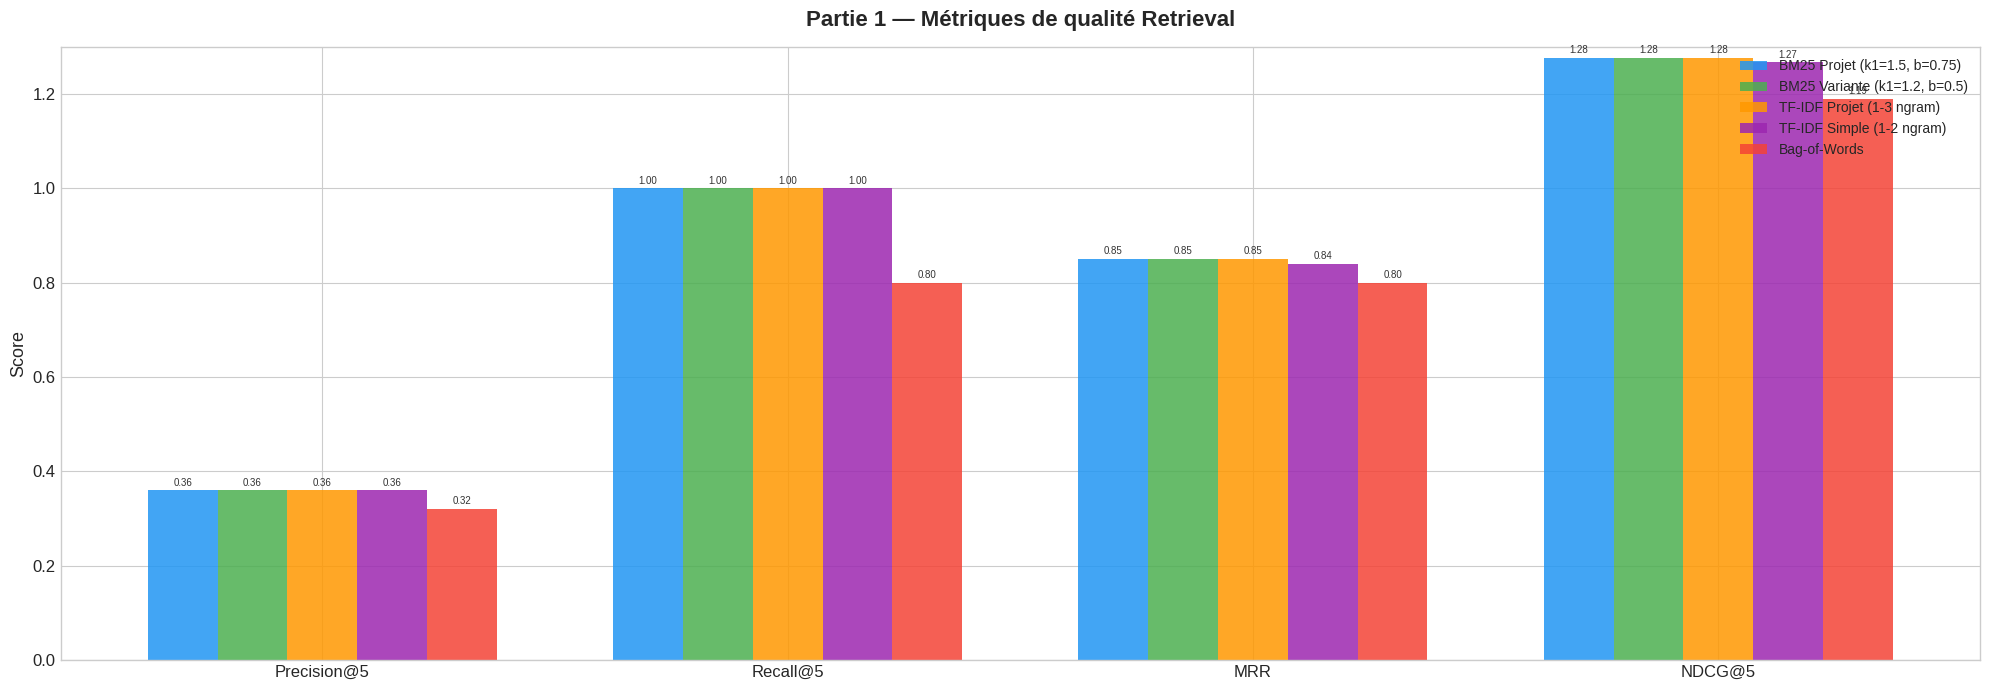

✅ Graphe 1a sauvegardé


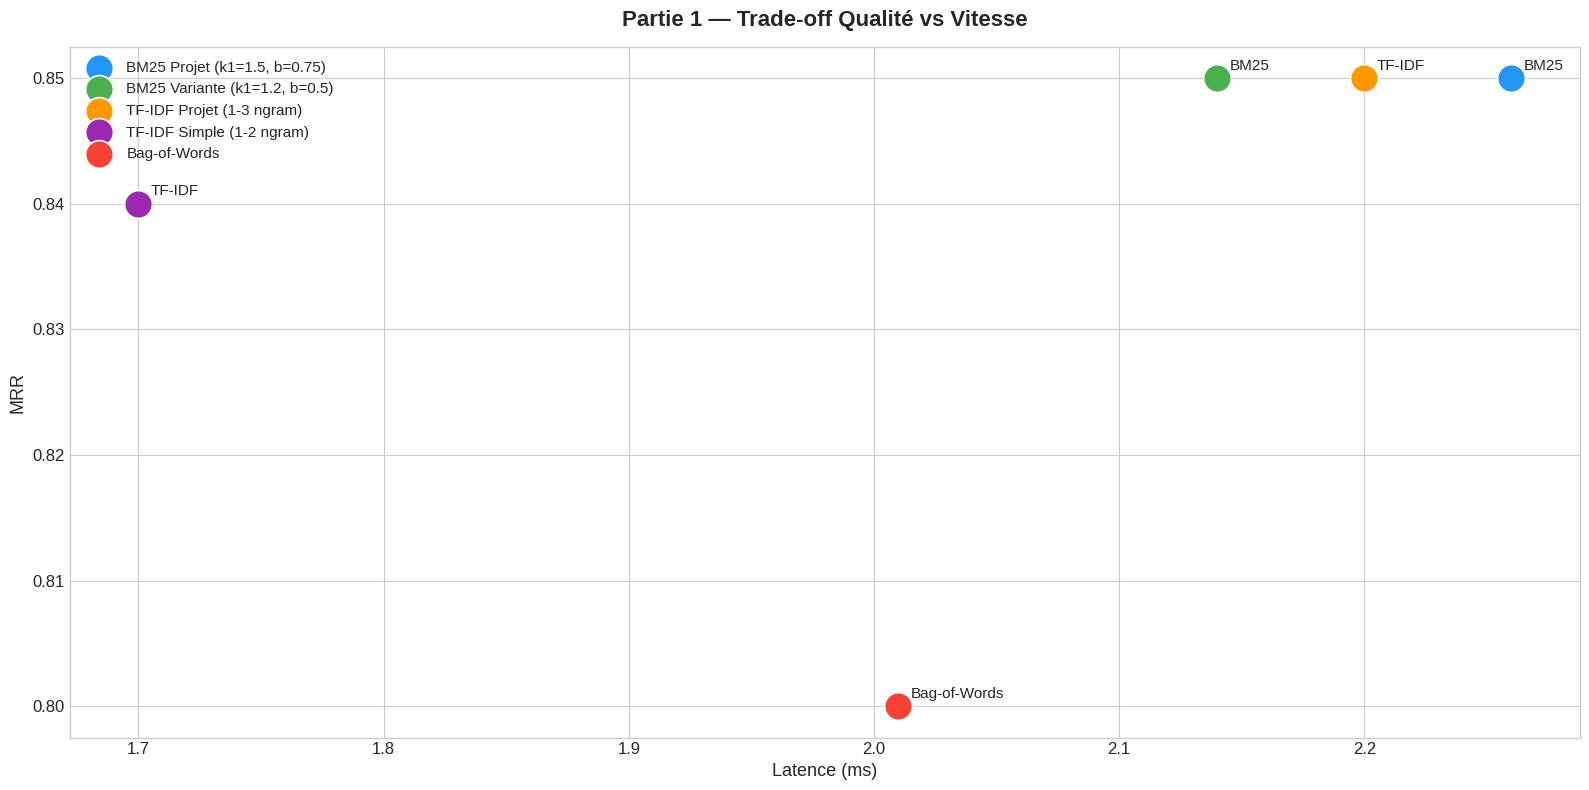

✅ Graphe 1b sauvegardé


In [33]:
# ── Visualisation Partie 1 — graphes séparés et larges ────────────────────────
colors_r = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']

# Graphe 1a — Métriques de qualité
fig, ax = plt.subplots(figsize=(20, 7))
metrics = ['Precision@5','Recall@5','MRR','NDCG@5']
x = np.arange(len(metrics)); width = 0.15
for i, (_, row) in enumerate(retrieval_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=row['Modèle'], color=colors_r[i], alpha=0.85)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{val:.2f}", ha='center', fontsize=7, color='#333333')
ax.set_xticks(x + width*2); ax.set_xticklabels(metrics, fontsize=14)
ax.set_ylim(0, 1.3); ax.set_ylabel('Score', fontsize=13)
ax.set_title('Partie 1 — Métriques de qualité Retrieval', fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.savefig('partie1a_qualite.png', dpi=150, bbox_inches='tight')
plt.show(); print("✅ Graphe 1a sauvegardé")

# Graphe 1b — Trade-off Qualité vs Vitesse
fig, ax = plt.subplots(figsize=(16, 8))
for i, (_, row) in enumerate(retrieval_df.iterrows()):
    ax.scatter(row['Latence (ms)'], row['MRR'], color=colors_r[i], s=400,
               label=row['Modèle'], zorder=5, edgecolors='white', linewidths=1.2)
    ax.annotate(row['Modèle'].split()[0], (row['Latence (ms)'], row['MRR']),
                xytext=(9, 6), textcoords='offset points', fontsize=11)
ax.set_xlabel('Latence (ms)', fontsize=13); ax.set_ylabel('MRR', fontsize=13)
ax.set_title('Partie 1 — Trade-off Qualité vs Vitesse', fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=11); ax.tick_params(labelsize=12)
plt.tight_layout()
plt.savefig('partie1b_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show(); print("✅ Graphe 1b sauvegardé")


## 🔀 PARTIE 2 — Comparaison des stratégies de FUSION
RRF (Projet) vs Score Moyen vs Score Max

In [34]:
def rrf_fusion(results_list, k=60, top_k=10):
    scores = {}
    for ranked_idx in results_list:
        for rank, doc_id in enumerate(ranked_idx, 1):
            scores[doc_id] = scores.get(doc_id, 0) + 1/(k + rank)
    sorted_docs = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    idx   = np.array([d[0] for d in sorted_docs[:top_k]])
    sco   = np.array([d[1] for d in sorted_docs[:top_k]])
    return idx, sco

def avg_score_fusion(idx_score_list, n_docs, top_k=10):
    combined = np.zeros(n_docs)
    for idx, scores in idx_score_list:
        norm = scores / (scores.max() + 1e-9)
        combined[idx] += norm
    combined /= len(idx_score_list)
    top_idx = np.argsort(combined)[::-1][:top_k]
    return top_idx, combined[top_idx]

def max_score_fusion(idx_score_list, n_docs, top_k=10):
    combined = np.zeros(n_docs)
    for idx, scores in idx_score_list:
        norm = scores / (scores.max() + 1e-9)
        np.maximum.at(combined, idx, norm)
    top_idx = np.argsort(combined)[::-1][:top_k]
    return top_idx, combined[top_idx]

print("✅ Fonctions de fusion définies")


✅ Fonctions de fusion définies


In [35]:
fusion_results = []
n_docs = len(passages)

FUSION_STRATEGIES = {
    "RRF k=60 [PROJET]": lambda q, k: rrf_fusion(
        [bm25_project.score(q, top_k=20)[0], run_tfidf(tfidf_project, tfidf_matrix_project, q, 20)[0]], k=60, top_k=k),
    "Score Moyen": lambda q, k: avg_score_fusion(
        [bm25_project.score(q, top_k=20), run_tfidf(tfidf_project, tfidf_matrix_project, q, 20)], n_docs, top_k=k),
    "Score Max": lambda q, k: max_score_fusion(
        [bm25_project.score(q, top_k=20), run_tfidf(tfidf_project, tfidf_matrix_project, q, 20)], n_docs, top_k=k),
    "RRF k=30": lambda q, k: rrf_fusion(
        [bm25_project.score(q, top_k=20)[0], run_tfidf(tfidf_project, tfidf_matrix_project, q, 20)[0]], k=30, top_k=k),
    "RRF k=100": lambda q, k: rrf_fusion(
        [bm25_project.score(q, top_k=20)[0], run_tfidf(tfidf_project, tfidf_matrix_project, q, 20)[0]], k=100, top_k=k),
}

for strat_name, strat_fn in FUSION_STRATEGIES.items():
    print(f"\n📊 [{strat_name}]")
    p5_l, r5_l, mrr_l, ndcg_l, lat_l = [], [], [], [], []
    for query, expected, desc in TEST_QUERIES:
        t0 = time.time()
        idx, _ = strat_fn(query, 10)
        lat = (time.time()-t0)*1000
        names = df.iloc[idx]['product_name'].tolist()
        p5_l.append(precision_at_k(names, expected))
        r5_l.append(recall_at_k(names, expected))
        mrr_l.append(mrr(names, expected))
        ndcg_l.append(ndcg_at_k(names, expected))
        lat_l.append(lat)
        print(f"   '{query[:38]:<38}' MRR={mrr_l[-1]:.2f} NDCG={ndcg_l[-1]:.2f} {lat:.0f}ms")
    fusion_results.append({
        "Stratégie":    strat_name,
        "Precision@5":  round(np.mean(p5_l),3),
        "Recall@5":     round(np.mean(r5_l),3),
        "MRR":          round(np.mean(mrr_l),3),
        "NDCG@5":       round(np.mean(ndcg_l),3),
        "Latence (ms)": round(np.mean(lat_l),2),
    })

fusion_df = pd.DataFrame(fusion_results)
print("\n" + "="*70)
print(tabulate(fusion_df.set_index('Stratégie'), headers='keys', tablefmt='fancy_grid', floatfmt='.3f'))
print(f"\n🏆 Meilleure fusion (MRR) : {fusion_df.loc[fusion_df['MRR'].idxmax(),'Stratégie']}")



📊 [RRF k=60 [PROJET]]
   'Aktiv Vital Arteres                   ' MRR=1.00 NDCG=1.00 6ms
   'complément alimentaire circulation    ' MRR=0.25 NDCG=0.43 6ms
   'produit minceur gélule                ' MRR=1.00 NDCG=1.00 5ms
   'omega 3 yeux                          ' MRR=1.00 NDCG=1.00 4ms
   'ferbiotic                             ' MRR=1.00 NDCG=2.95 3ms

📊 [Score Moyen]
   'Aktiv Vital Arteres                   ' MRR=1.00 NDCG=1.00 5ms
   'complément alimentaire circulation    ' MRR=0.25 NDCG=0.43 5ms
   'produit minceur gélule                ' MRR=1.00 NDCG=1.00 5ms
   'omega 3 yeux                          ' MRR=1.00 NDCG=1.00 5ms
   'ferbiotic                             ' MRR=1.00 NDCG=2.95 3ms

📊 [Score Max]
   'Aktiv Vital Arteres                   ' MRR=1.00 NDCG=1.00 5ms
   'complément alimentaire circulation    ' MRR=0.25 NDCG=0.43 5ms
   'produit minceur gélule                ' MRR=1.00 NDCG=1.00 4ms
   'omega 3 yeux                          ' MRR=1.00 NDCG=1.00 4ms
   'fer

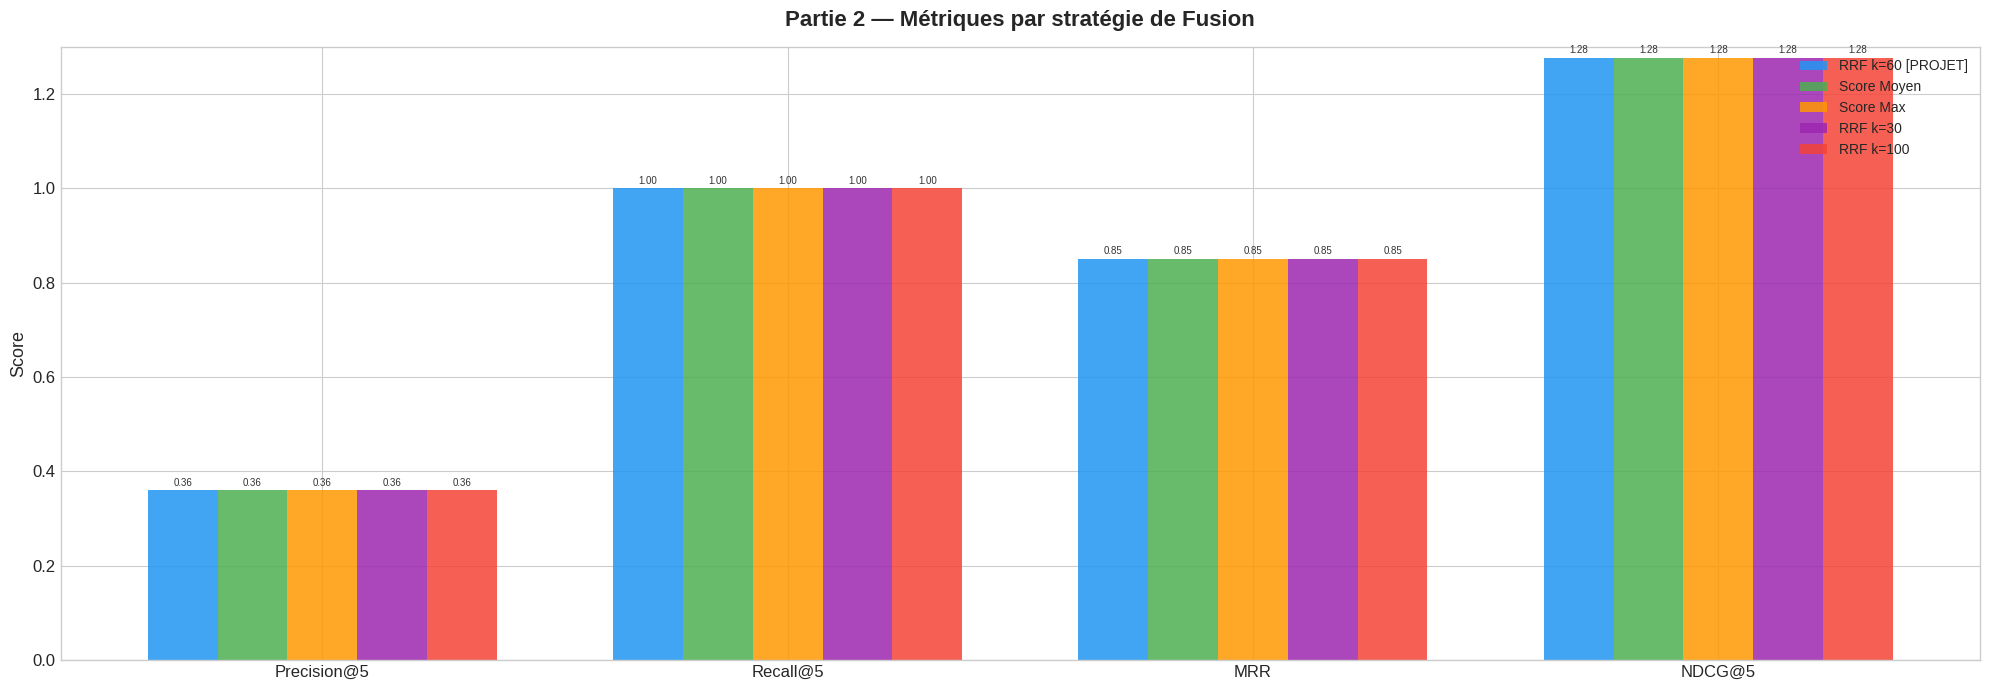

✅ Graphe 2a sauvegardé


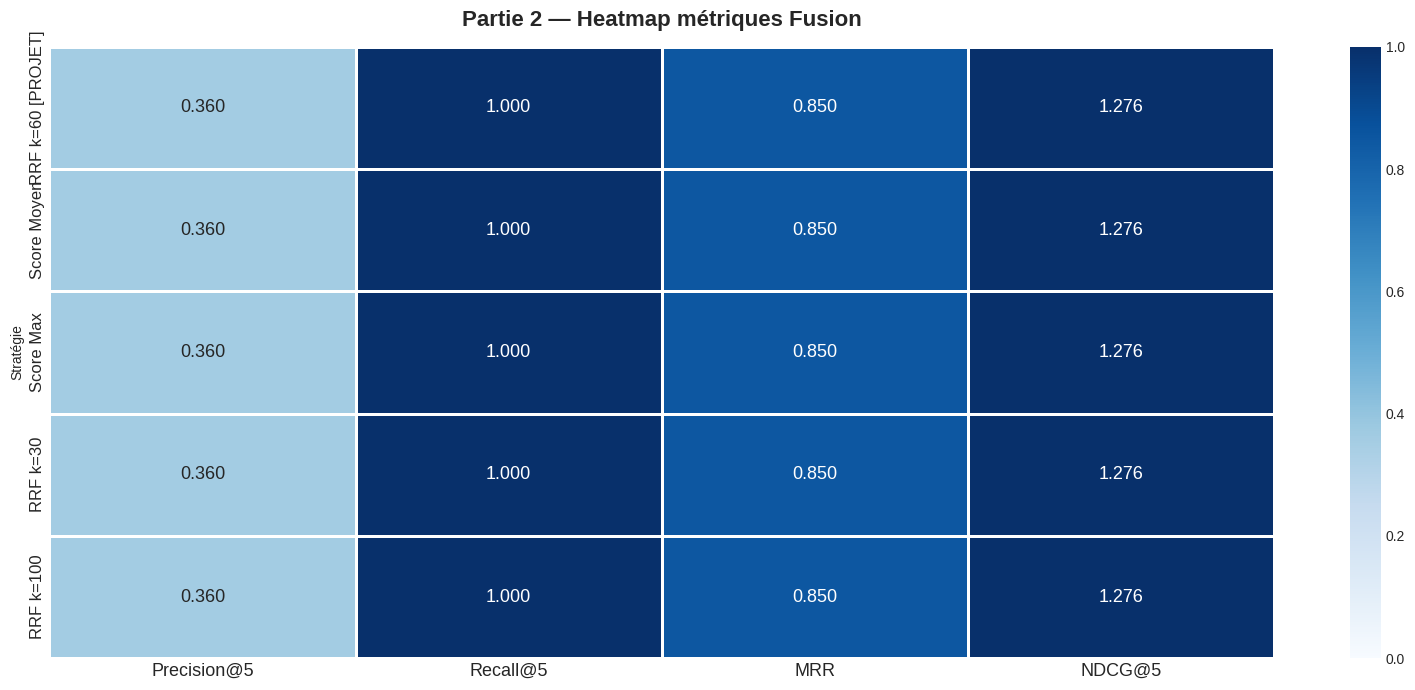

✅ Graphe 2b sauvegardé


In [36]:
# ── Visualisation Partie 2 — graphes séparés et larges ────────────────────────
colors_f = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
metrics_f = ['Precision@5','Recall@5','MRR','NDCG@5']

# Graphe 2a — Barres métriques
fig, ax = plt.subplots(figsize=(20, 7))
x = np.arange(len(metrics_f)); width = 0.15
for i, (_, row) in enumerate(fusion_df.iterrows()):
    vals = [row[m] for m in metrics_f]
    bars = ax.bar(x + i*width, vals, width, label=row['Stratégie'], color=colors_f[i%len(colors_f)], alpha=0.85)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{val:.2f}", ha='center', fontsize=7, color='#333333')
ax.set_xticks(x + width*2); ax.set_xticklabels(metrics_f, fontsize=14)
ax.set_ylim(0, 1.3); ax.set_ylabel('Score', fontsize=13)
ax.set_title('Partie 2 — Métriques par stratégie de Fusion', fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.savefig('partie2a_fusion_barres.png', dpi=150, bbox_inches='tight')
plt.show(); print("✅ Graphe 2a sauvegardé")

# Graphe 2b — Heatmap fusion
fig, ax = plt.subplots(figsize=(16, 7))
heat_data = fusion_df.set_index('Stratégie')[metrics_f]
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='Blues', ax=ax,
            vmin=0, vmax=1, linewidths=0.8, annot_kws={"size": 13})
ax.set_title('Partie 2 — Heatmap métriques Fusion', fontsize=16, fontweight='bold', pad=15)
ax.tick_params(axis='y', labelsize=12); ax.tick_params(axis='x', labelsize=13)
plt.tight_layout()
plt.savefig('partie2b_fusion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show(); print("✅ Graphe 2b sauvegardé")


## 🤖 PARTIE 3 — Comparaison LLM (Groq + OpenRouter)

**Modèles testés — 100% actifs en avril 2026 :**
- **Groq** : Llama 3.1 8b, Llama 3.3 70b, Llama 4 Scout, GPT-OSS 20b/120b, Qwen3 32b, Kimi K2
- **OpenRouter** : Llama 3.3 70b, DeepSeek R1, Gemma 3 12b, Qwen 2.5 72b, Trinity Large
- ❌ Modèles en erreur → **exclus automatiquement**
- Chaque graphe est **séparé et agrandi**


In [37]:
# ── Clients API ───────────────────────────────────────────────────────────────

def call_groq(prompt, model, api_key, max_tokens=400, max_retries=2, retry_delay=8.0):
    url = "https://api.groq.com/openai/v1/chat/completions"
    headers = {"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"}
    body = {"model": model, "messages": [{"role": "user", "content": prompt}],
            "max_tokens": max_tokens, "temperature": 0.3}
    for attempt in range(1, max_retries + 1):
        t0 = time.time()
        try:
            resp    = requests.post(url, headers=headers, json=body, timeout=60)
            latency = (time.time() - t0) * 1000
            if resp.status_code == 429:
                if attempt < max_retries:
                    wait = retry_delay * attempt
                    print(f"         ⏳ Rate limit — attente {wait:.0f}s...")
                    time.sleep(wait); continue
                return {"response":"","latency_ms":latency,"tokens_out":0,
                        "error":f"Rate limit (429) après {max_retries} essais"}
            if resp.status_code not in (200, 201):
                return {"response":"","latency_ms":latency,"tokens_out":0,
                        "error":f"HTTP {resp.status_code}: {resp.text[:120]}"}
            data = resp.json()
            text = data["choices"][0]["message"]["content"]
            toks = data.get("usage",{}).get("completion_tokens", len(text.split()))
            return {"response":text,"latency_ms":latency,"tokens_out":toks,"error":None}
        except Exception as e:
            latency = (time.time()-t0)*1000
            if attempt < max_retries: time.sleep(retry_delay); continue
            return {"response":"","latency_ms":latency,"tokens_out":0,"error":str(e)[:100]}
    return {"response":"","latency_ms":0,"tokens_out":0,"error":"Max retries"}


def call_openrouter(prompt, model, api_key, max_tokens=400):
    url = "https://openrouter.ai/api/v1/chat/completions"
    headers = {"Authorization": f"Bearer {api_key}", "Content-Type": "application/json",
               "HTTP-Referer": "https://vital-agent.com", "X-Title": "VITAL-AGENT"}
    body = {"model": model, "messages": [{"role": "user", "content": prompt}],
            "max_tokens": max_tokens, "temperature": 0.3}
    t0 = time.time()
    try:
        resp    = requests.post(url, headers=headers, json=body, timeout=90)
        latency = (time.time() - t0) * 1000
        if resp.status_code not in (200, 201):
            return {"response":"","latency_ms":latency,"tokens_out":0,
                    "error":f"HTTP {resp.status_code}: {resp.text[:120]}"}
        data = resp.json()
        text = data["choices"][0]["message"]["content"]
        toks = data.get("usage",{}).get("completion_tokens", len(text.split()))
        return {"response":text,"latency_ms":latency,"tokens_out":toks,"error":None}
    except Exception as e:
        return {"response":"","latency_ms":(time.time()-t0)*1000,"tokens_out":0,"error":str(e)[:100]}


def call_model(prompt, m, max_tokens=400):
    if m["provider"] == "groq":
        return call_groq(prompt, m["model"], GROQ_KEYS[m["key_index"]], max_tokens)
    elif m["provider"] == "openrouter":
        return call_openrouter(prompt, m["model"], OPENROUTER_KEY, max_tokens)
    return {"response":"","latency_ms":0,"tokens_out":0,"error":"Unknown provider"}

print("✅ Clients Groq + OpenRouter prêts")


✅ Clients Groq + OpenRouter prêts


In [38]:
# ── Contexte RAG + Cas de test ────────────────────────────────────────────────
tfidf_llm        = TfidfVectorizer(analyzer='word', ngram_range=(1,3), min_df=1, max_features=25000, sublinear_tf=True)
tfidf_matrix_llm = tfidf_llm.fit_transform(passages)

def build_context(query, top_k=5):
    q   = tfidf_llm.transform([query])
    sim = cosine_similarity(q, tfidf_matrix_llm).flatten()
    idx = np.argsort(sim)[::-1][:top_k]
    parts = []
    for i, ri in enumerate(idx, 1):
        row = df.iloc[ri]
        parts.append(f"[{i}] {row.get('product_name','')} | Prix: {row.get('price','')} TND | "
                     f"Stock: {row.get('stock_status','')} | Tendance: {row.get('global_category_trend','')}")
    return "\n".join(parts)

LLM_TEST_CASES = [
    {"name": "Analyse commerciale",
     "context_query": "Aktiv Vital produits commerciaux",
     "query": "Quels produits Aktiv Vital ont le plus fort potentiel commercial ? Justifie avec des données.",
     "evaluation": ["mentionne des produits spécifiques","cite des métriques ou des critères",
                    "donne une recommandation claire","structure la réponse"]},
    {"name": "Identification risques",
     "context_query": "produits rupture stock risque",
     "query": "Identifie les produits en rupture de stock critique et propose des actions urgentes.",
     "evaluation": ["identifie le problème de rupture","propose des actions concrètes",
                    "mentionne l'urgence","structure la réponse"]},
    {"name": "Stratégie produit",
     "context_query": "gamme Ferbiotic stratégie développement",
     "query": "Quelle stratégie adopter pour développer la gamme Ferbiotic sur le marché tunisien ?",
     "evaluation": ["mentionne Ferbiotic","propose des axes stratégiques",
                    "cite des métriques ou des critères","structure la réponse"]},
]

def score_response(response, test_case):
    if not response or len(response) < 10:
        return {"completeness":0,"length_score":0,"criteria_hit":0,"french_score":0}
    nw = len(response.split()); nc = len(response)
    length_score = 1.0 if 80<=nw<=400 else (nw/80 if nw<80 else max(0.5, 1.0-(nw-400)/400))
    crit_map = {
        "mentionne des produits spécifiques":   any(w in response.lower() for w in df['product_name'].str.lower().tolist()[:50]),
        "cite des métriques ou des critères":   any(w in response.lower() for w in ['prix','tendance','stock','croissance','risque','score']),
        "donne une recommandation claire":      any(w in response.lower() for w in ['recommande','conseil','priorité','faut','devrait','important']),
        "identifie le problème de rupture":     any(w in response.lower() for w in ['rupture','stock','indisponible','manque']),
        "propose des actions concrètes":        any(w in response.lower() for w in ['action','faire','augmenter','réapprovisionnement','contacter']),
        "mentionne l'urgence":                  any(w in response.lower() for w in ['urgent','immédiat','rapidement','prioritaire','dès']),
        "structure la réponse":                 response.count('\n')>=3 or any(c in response for c in ['•','-','1.','**']),
        "mentionne Ferbiotic":                  'ferbiotic' in response.lower(),
        "propose des axes stratégiques":        any(w in response.lower() for w in ['stratégie','stratégique','développer','consolider','investir']),
    }
    crit_hit = sum(crit_map.get(c, False) for c in test_case.get("evaluation",[]))
    crit_hit /= max(len(test_case.get("evaluation",["x"])),1)
    fr_words = {'le','la','les','de','du','un','une','des','et','en','est','pour','avec','dans','que','qui','sur','par','au','aux'}
    french_score = min(1.0, len(fr_words & set(response.lower().split())) / 8)
    return {"completeness":round(min(1.0,nc/300),3),"length_score":round(min(1.0,length_score),3),
            "criteria_hit":round(crit_hit,3),"french_score":round(french_score,3)}

print(f"✅ {len(LLM_TEST_CASES)} cas de test LLM définis")


✅ 3 cas de test LLM définis


In [39]:
# ══════════════════════════════════════════════════════════════════════════════
# 🚀  BENCHMARK LLM — GROQ + OPENROUTER
# ══════════════════════════════════════════════════════════════════════════════
llm_all_results   = []
llm_failed_models = []

def run_model_benchmark(m):
    scores_list, latencies, tokens_list = [], [], []
    all_failed = True
    for tc in LLM_TEST_CASES:
        ctx    = build_context(tc["context_query"], top_k=5)
        prompt = (
            "Tu es un assistant commercial expert pour la parapharmacie Vital (Tunisie).\n"
            f"Données produits :\n{ctx}\n\n"
            f"Question : {tc['query']}\n"
            "Réponds en français, de façon structurée et actionnable."
        )
        result = call_model(prompt, m, max_tokens=400)
        if result["error"]:
            print(f"     ⚠️  [{tc['name']}] {result['error'][:80]}")
            scores_list.append({"completeness":0,"length_score":0,"criteria_hit":0,"french_score":0})
        else:
            all_failed = False
            sc = score_response(result["response"], tc)
            scores_list.append(sc)
            preview = result["response"][:75].replace("\n"," ")
            print(f"     ✅ [{tc['name']}] Crit={sc['criteria_hit']:.2f} | {result['latency_ms']:.0f}ms | \"{preview}...\"")
        latencies.append(result["latency_ms"])
        tokens_list.append(result["tokens_out"])
        time.sleep(1.5)
    if all_failed:
        return None
    avg = {k: round(np.mean([s[k] for s in scores_list]),3)
           for k in ["completeness","length_score","criteria_hit","french_score"]}
    return {
        "Modèle":       m["label"],
        "Model ID":     m["model"],
        "Provider":     m["provider"].capitalize(),
        "Complétude":   avg["completeness"],
        "Longueur OK":  avg["length_score"],
        "Critères":     avg["criteria_hit"],
        "Français":     avg["french_score"],
        "Score Global": round(np.mean(list(avg.values())),3),
        "Latence (ms)": round(np.mean(latencies),0),
        "Tokens/rep":   round(np.mean(tokens_list),0),
    }

for m in ALL_MODELS:
    print(f"\n{'='*65}")
    print(f"🤖  {m['label']}  ({m['provider'].upper()} | {m['model']})")
    print("-"*65)
    result = run_model_benchmark(m)
    if result:
        llm_all_results.append(result)
        print(f"   → ✅ Inclus | Score Global : {result['Score Global']:.3f}")
    else:
        llm_failed_models.append(m["label"])
        print(f"   → ❌ EXCLU (toutes les requêtes ont échoué)")
    time.sleep(3)

llm_df = (pd.DataFrame(llm_all_results)
            .sort_values("Score Global", ascending=False)
            .reset_index(drop=True))

print("\n" + "="*80)
print("📊  RÉSULTATS FINAUX — MODÈLES FONCTIONNELS UNIQUEMENT")
print("="*80)
print(tabulate(
    llm_df[["Modèle","Provider","Score Global","Critères","Complétude","Français","Latence (ms)","Tokens/rep"]].set_index("Modèle"),
    headers="keys", tablefmt="fancy_grid", floatfmt=".3f"
))
if llm_failed_models:
    print(f"\n❌ Modèles exclus ({len(llm_failed_models)}) : {', '.join(llm_failed_models)}")
if len(llm_df) > 0:
    print(f"\n🏆 Meilleur LLM  : {llm_df.iloc[0]['Modèle']}  (score={llm_df.iloc[0]['Score Global']:.3f})")
    print(f"⚡ Plus rapide   : {llm_df.loc[llm_df['Latence (ms)'].idxmin(),'Modèle']}  ({llm_df['Latence (ms)'].min():.0f}ms)")



🤖  Llama 3.1 8b  (GROQ | llama-3.1-8b-instant)
-----------------------------------------------------------------
     ✅ [Analyse commerciale] Crit=0.75 | 868ms | "**Analyse du potentiel commercial des produits Aktiv Vital**  Pour détermin..."
     ✅ [Identification risques] Crit=1.00 | 968ms | "**Analyse de la situation de stock**  Après avoir examiné les données des p..."
     ✅ [Stratégie produit] Crit=1.00 | 1429ms | "**Stratégie de développement de la gamme Ferbiotic sur le marché tunisien**..."
   → ✅ Inclus | Score Global : 0.979

🤖  Llama 3.3 70b  (GROQ | llama-3.3-70b-versatile)
-----------------------------------------------------------------
     ✅ [Analyse commerciale] Crit=0.75 | 989ms | "**Analyse du Potentiel Commercial des Produits Aktiv Vital**  En tant qu'as..."
     ✅ [Identification risques] Crit=1.00 | 1940ms | "**Analyse de la situation**  En analysant les données produits, nous consta..."
     ✅ [Stratégie produit] Crit=1.00 | 1267ms | "**Stratégie de développeme

### 📊 Graphiques Partie 3 — Séparés, larges, lisibles

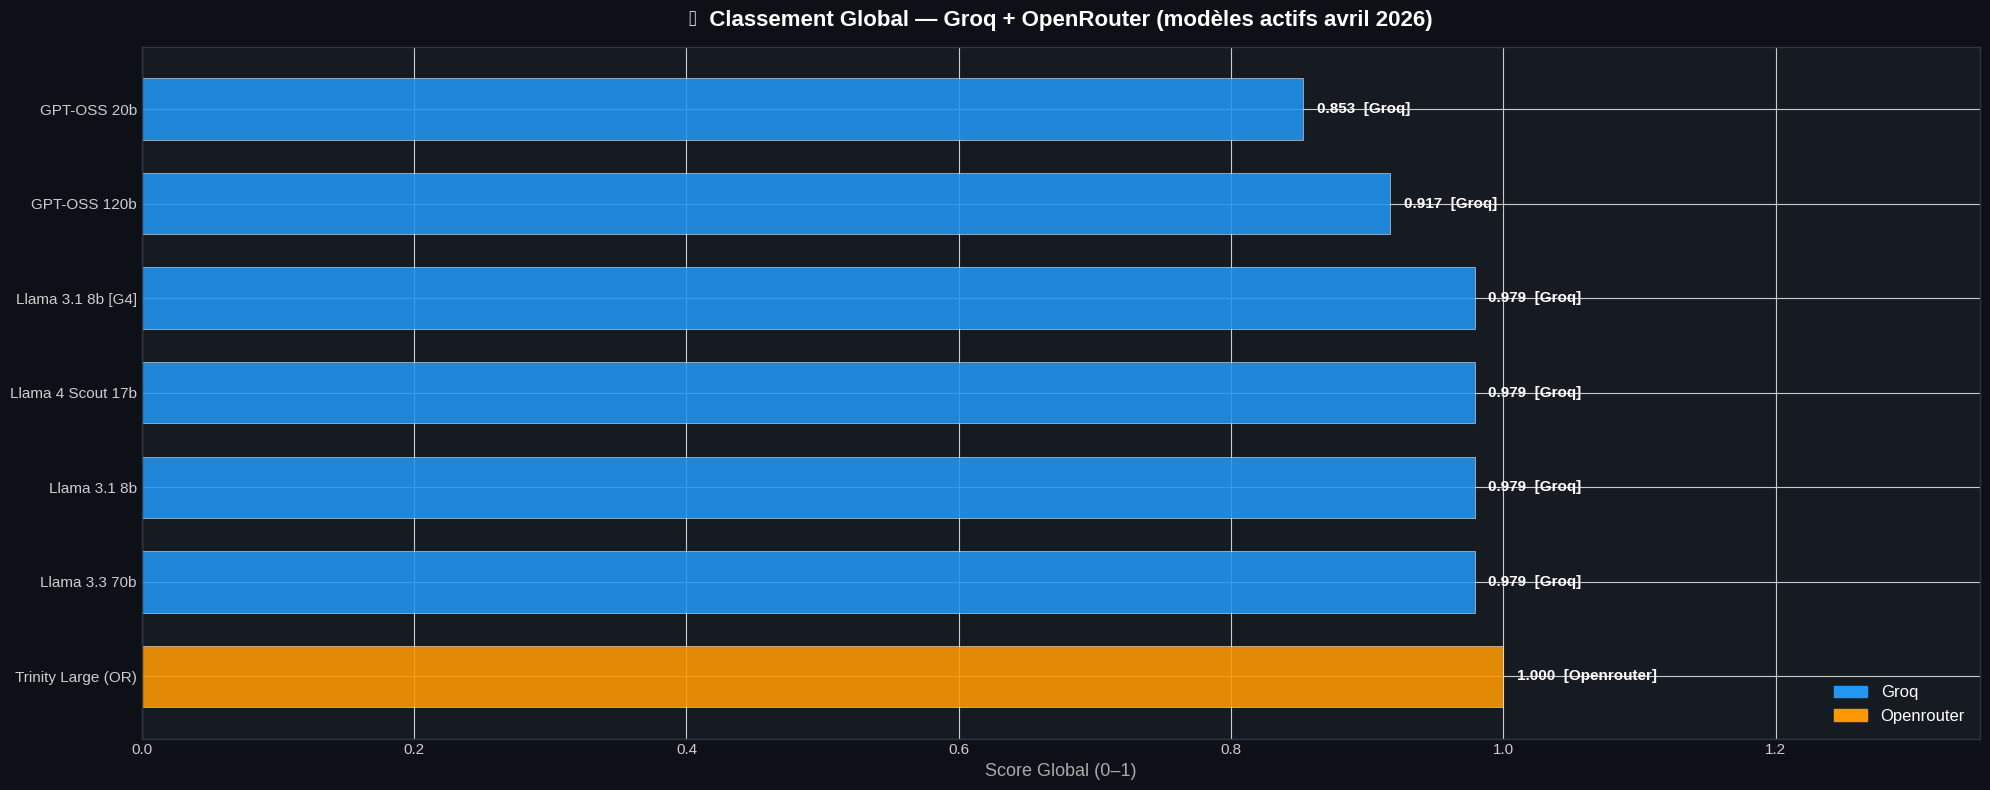

✅ Graphe 3-1 sauvegardé


In [40]:
PROVIDER_COLORS = {"Groq": "#2196F3", "Openrouter": "#FF9800"}

def get_color(provider):
    return PROVIDER_COLORS.get(provider, "#9E9E9E")

if len(llm_df) == 0:
    print("⚠️  Aucun modèle valide")
else:
    df_plot = llm_df.copy(); n = len(df_plot)
    colors  = [get_color(p) for p in df_plot["Provider"]]
    m_cols  = ["Complétude","Longueur OK","Critères","Français"]

    # ── Graphe 3-1 : Classement Global ───────────────────────────────────────
    fig, ax = plt.subplots(figsize=(20, max(8, n * 0.65 + 2)), facecolor="#0D1117")
    ax.set_facecolor("#161B22")
    bars = ax.barh(np.arange(n), df_plot["Score Global"], color=colors,
                   alpha=0.88, edgecolor="white", linewidth=0.4, height=0.65)
    for bar, val, prov in zip(bars, df_plot["Score Global"], df_plot["Provider"]):
        ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                f"{val:.3f}  [{prov}]", va="center", fontsize=11, color="white", fontweight="bold")
    ax.set_yticks(np.arange(n))
    ax.set_yticklabels(df_plot["Modèle"], fontsize=12, color="#DDDDDD")
    ax.set_xlabel("Score Global (0–1)", fontsize=13, color="#AAAAAA")
    ax.set_title("🏆  Classement Global — Groq + OpenRouter (modèles actifs avril 2026)",
                 fontsize=16, fontweight="bold", color="white", pad=15)
    ax.set_xlim(0, 1.35); ax.tick_params(colors="#CCCCCC", labelsize=11)
    ax.spines[:].set_color("#30363D")
    patches_legend = [mpatches.Patch(color=c, label=k) for k,c in PROVIDER_COLORS.items()]
    ax.legend(handles=patches_legend, fontsize=12, framealpha=0.3, labelcolor="white",
              facecolor="#161B22", loc="lower right")
    plt.tight_layout()
    plt.savefig("p3_1_classement_global.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
    plt.show(); print("✅ Graphe 3-1 sauvegardé")


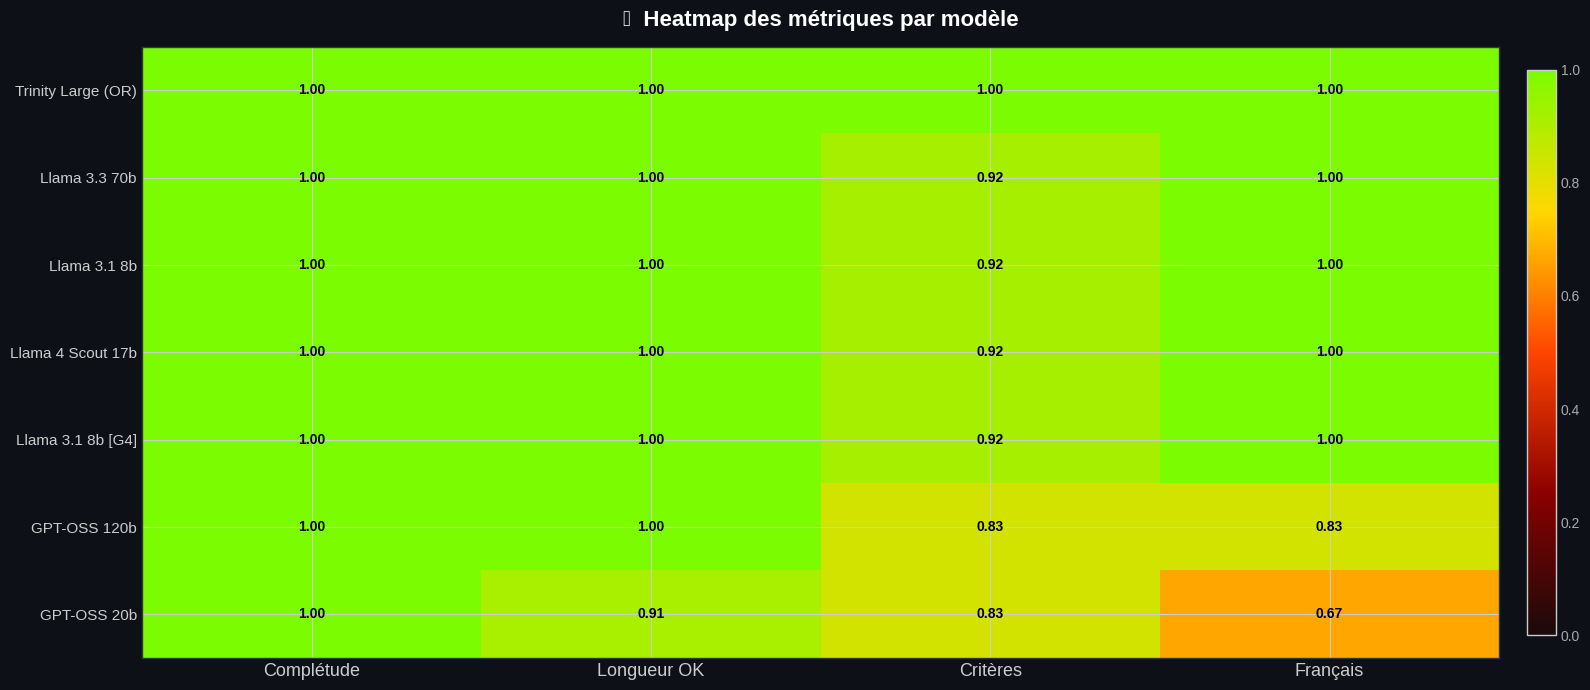

✅ Graphe 3-2 sauvegardé


In [41]:
if len(llm_df) > 0:
    df_plot = llm_df.copy(); n = len(df_plot)
    m_cols  = ["Complétude","Longueur OK","Critères","Français"]
    cmap    = LinearSegmentedColormap.from_list("dk",["#1A0A0A","#8B0000","#FF4500","#FFD700","#7CFC00"])

    # ── Graphe 3-2 : Heatmap ─────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(16, max(7, n * 0.6 + 2)), facecolor="#0D1117")
    ax.set_facecolor("#161B22")
    heat = df_plot.set_index("Modèle")[m_cols].values
    im   = ax.imshow(heat, aspect="auto", cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(len(m_cols))); ax.set_xticklabels(m_cols, fontsize=13, color="#CCCCCC")
    ax.set_yticks(range(n)); ax.set_yticklabels(df_plot["Modèle"], fontsize=11, color="#CCCCCC")
    ax.set_title("🔥  Heatmap des métriques par modèle", fontsize=16, fontweight="bold", color="white", pad=15)
    ax.spines[:].set_color("#30363D")
    for i in range(n):
        for j in range(len(m_cols)):
            v = heat[i,j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=10,
                    color="black" if v > 0.6 else "white", fontweight="bold")
    cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    cbar.ax.tick_params(colors="#AAAAAA", labelsize=10)
    plt.tight_layout()
    plt.savefig("p3_2_heatmap.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
    plt.show(); print("✅ Graphe 3-2 sauvegardé")


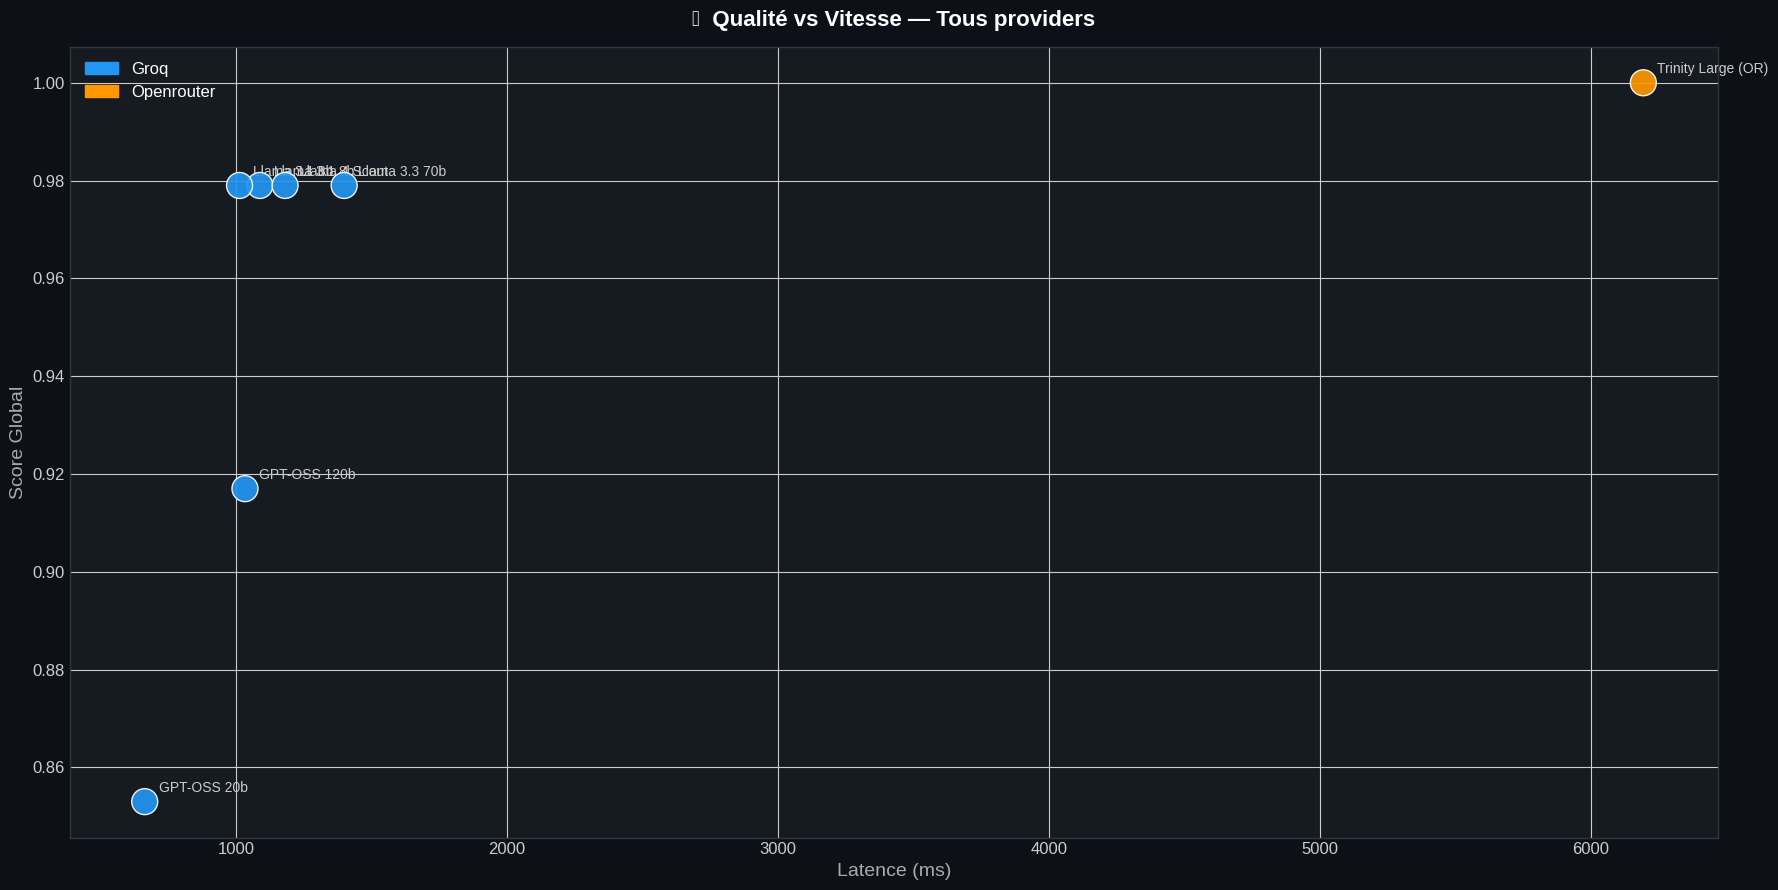

✅ Graphe 3-3 sauvegardé


In [42]:
if len(llm_df) > 0:
    df_plot = llm_df.copy(); n = len(df_plot)
    colors  = [get_color(p) for p in df_plot["Provider"]]

    # ── Graphe 3-3 : Qualité vs Vitesse ──────────────────────────────────────
    fig, ax = plt.subplots(figsize=(18, 9), facecolor="#0D1117")
    ax.set_facecolor("#161B22")
    ax.scatter(df_plot["Latence (ms)"], df_plot["Score Global"],
               c=colors, s=350, edgecolors="white", linewidths=1.0, zorder=5, alpha=0.92)
    for _, row in df_plot.iterrows():
        short = " ".join(row["Modèle"].split()[:3])
        ax.annotate(short, (row["Latence (ms)"], row["Score Global"]),
                    xytext=(10, 7), textcoords="offset points", fontsize=10, color="#CCCCCC")
    ax.set_xlabel("Latence (ms)", fontsize=14, color="#AAAAAA")
    ax.set_ylabel("Score Global", fontsize=14, color="#AAAAAA")
    ax.set_title("⚡  Qualité vs Vitesse — Tous providers", fontsize=16, fontweight="bold", color="white", pad=15)
    ax.tick_params(colors="#CCCCCC", labelsize=12); ax.spines[:].set_color("#30363D")
    patches_legend = [mpatches.Patch(color=c, label=k) for k,c in PROVIDER_COLORS.items()]
    ax.legend(handles=patches_legend, fontsize=12, framealpha=0.3, labelcolor="white", facecolor="#161B22")
    plt.tight_layout()
    plt.savefig("p3_3_qualite_vitesse.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
    plt.show(); print("✅ Graphe 3-3 sauvegardé")


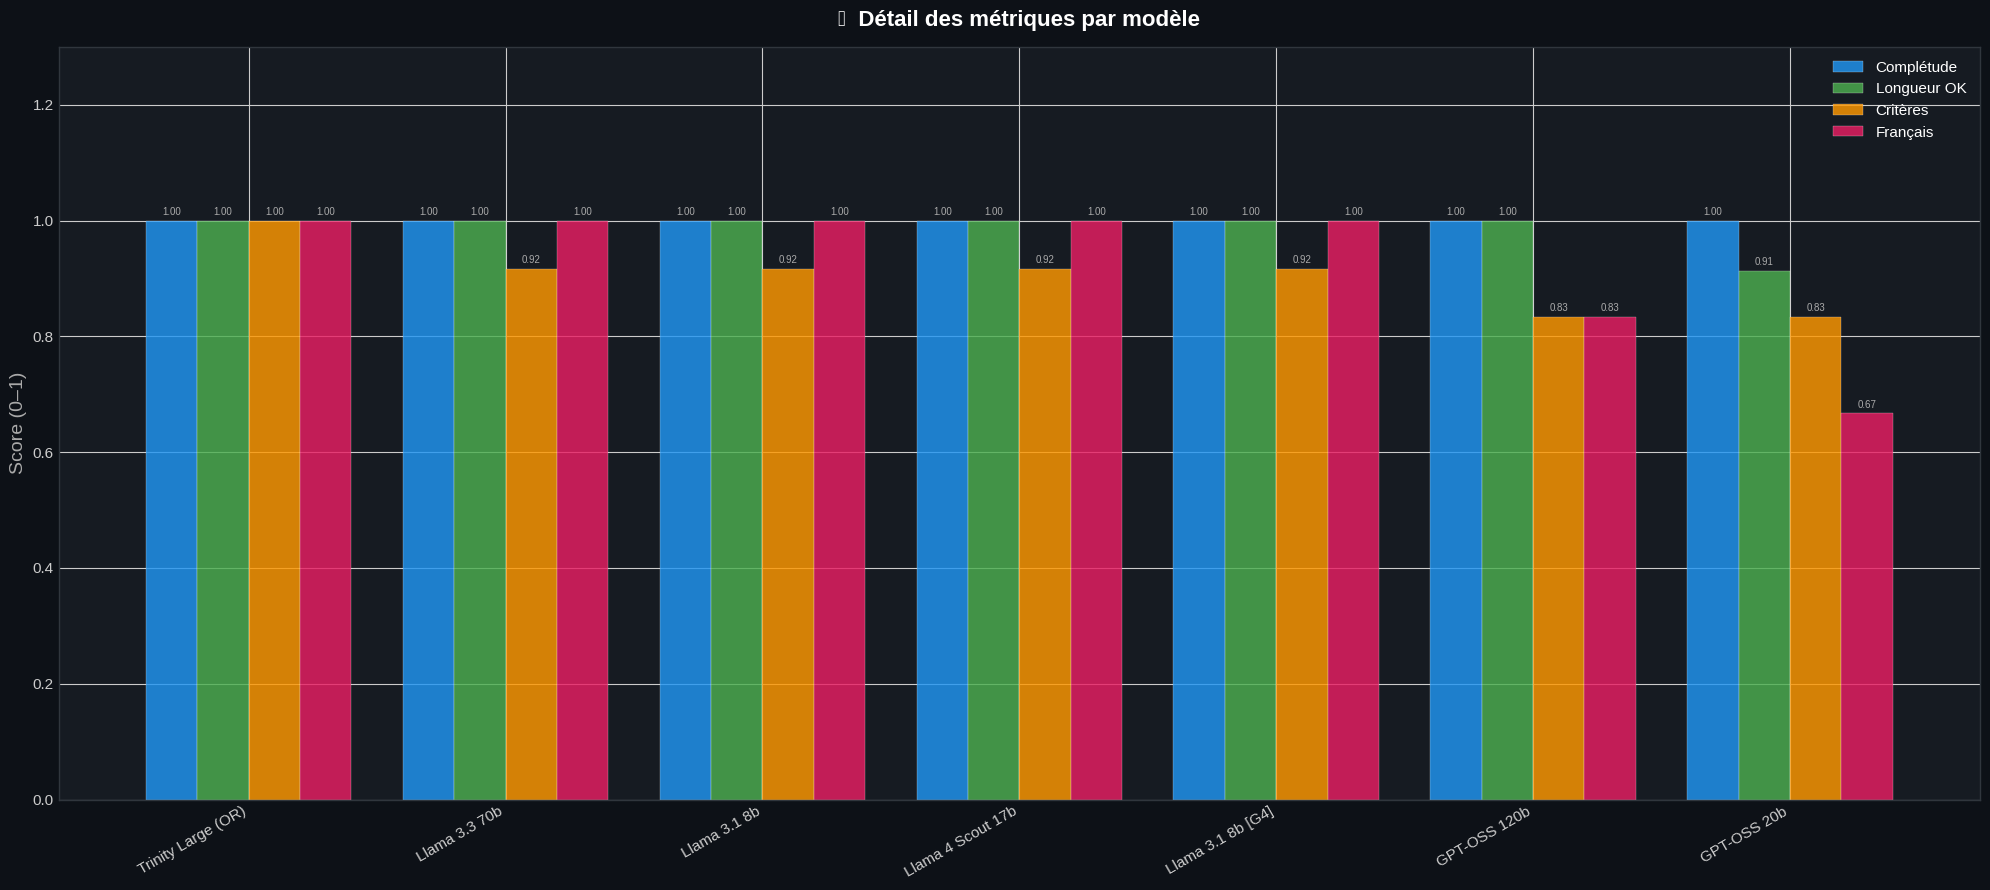

✅ Graphe 3-4 sauvegardé


In [43]:
if len(llm_df) > 0:
    df_plot = llm_df.copy(); n = len(df_plot)
    colors  = [get_color(p) for p in df_plot["Provider"]]
    m_cols  = ["Complétude","Longueur OK","Critères","Français"]
    mc_colors = ["#2196F3","#4CAF50","#FF9800","#E91E63"]

    # ── Graphe 3-4 : Scores détaillés ────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(max(20, n*1.3), 9), facecolor="#0D1117")
    ax.set_facecolor("#161B22")
    x_pos = np.arange(n); w = 0.2
    for j, (mc, col) in enumerate(zip(m_cols, mc_colors)):
        bars_d = ax.bar(x_pos + j*w, df_plot[mc], w, label=mc, color=col, alpha=0.82,
                        edgecolor="white", linewidth=0.2)
        for bar, val in zip(bars_d, df_plot[mc]):
            if val > 0:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                        f"{val:.2f}", ha="center", fontsize=7, color="#AAAAAA")
    ax.set_xticks(x_pos + w*1.5)
    ax.set_xticklabels(df_plot["Modèle"], rotation=30, ha="right", fontsize=10, color="#CCCCCC")
    ax.set_ylim(0, 1.3); ax.set_ylabel("Score (0–1)", fontsize=14, color="#AAAAAA")
    ax.set_title("📐  Détail des métriques par modèle", fontsize=16, fontweight="bold", color="white", pad=15)
    ax.legend(loc="upper right", fontsize=11, framealpha=0.3, labelcolor="white", facecolor="#161B22")
    ax.tick_params(colors="#CCCCCC", labelsize=11); ax.spines[:].set_color("#30363D")
    plt.tight_layout()
    plt.savefig("p3_4_detail_metriques.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
    plt.show(); print("✅ Graphe 3-4 sauvegardé")


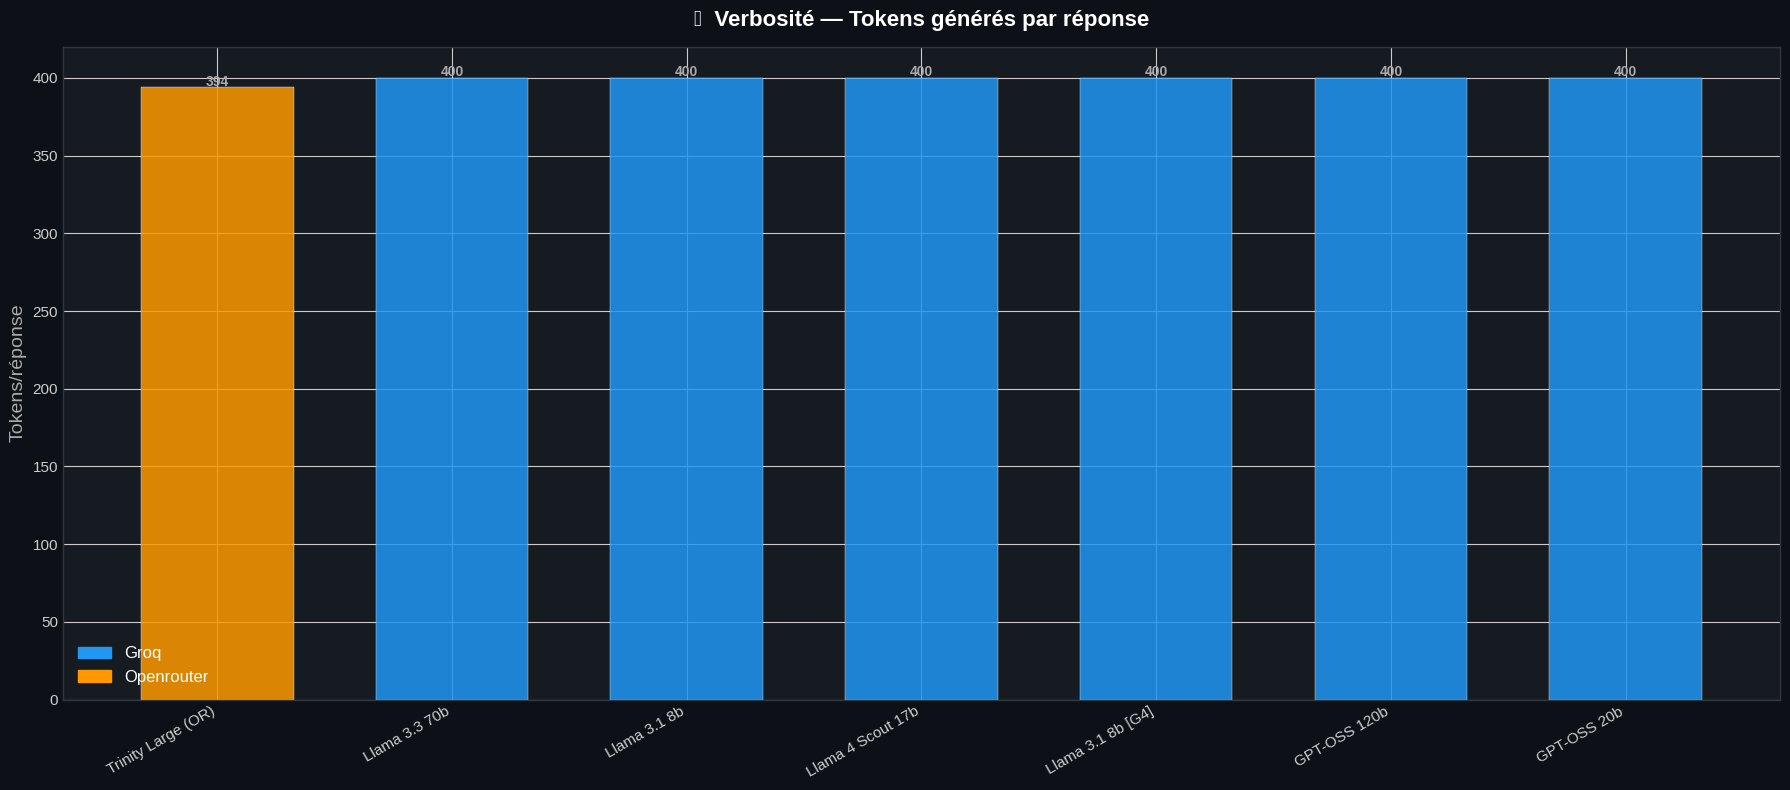

✅ Graphe 3-5 sauvegardé


In [44]:
if len(llm_df) > 0:
    df_plot = llm_df.copy(); n = len(df_plot)
    colors  = [get_color(p) for p in df_plot["Provider"]]

    # ── Graphe 3-5 : Verbosité ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(max(18, n*1.2), 8), facecolor="#0D1117")
    ax.set_facecolor("#161B22")
    b5 = ax.bar(range(n), df_plot["Tokens/rep"], color=colors, alpha=0.85, edgecolor="white", linewidth=0.3, width=0.65)
    ax.set_xticks(range(n))
    ax.set_xticklabels(df_plot["Modèle"], rotation=30, ha="right", fontsize=10, color="#CCCCCC")
    ax.set_ylabel("Tokens/réponse", fontsize=14, color="#AAAAAA")
    ax.set_title("📝  Verbosité — Tokens générés par réponse", fontsize=16, fontweight="bold", color="white", pad=15)
    ax.tick_params(colors="#CCCCCC", labelsize=11); ax.spines[:].set_color("#30363D")
    for bar, val in zip(b5, df_plot["Tokens/rep"]):
        if val > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                    f"{int(val)}", ha="center", fontsize=10, color="#AAAAAA", fontweight="bold")
    patches_legend = [mpatches.Patch(color=c, label=k) for k,c in PROVIDER_COLORS.items()]
    ax.legend(handles=patches_legend, fontsize=12, framealpha=0.3, labelcolor="white", facecolor="#161B22")
    plt.tight_layout()
    plt.savefig("p3_5_verbosité.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
    plt.show(); print("✅ Graphe 3-5 sauvegardé")


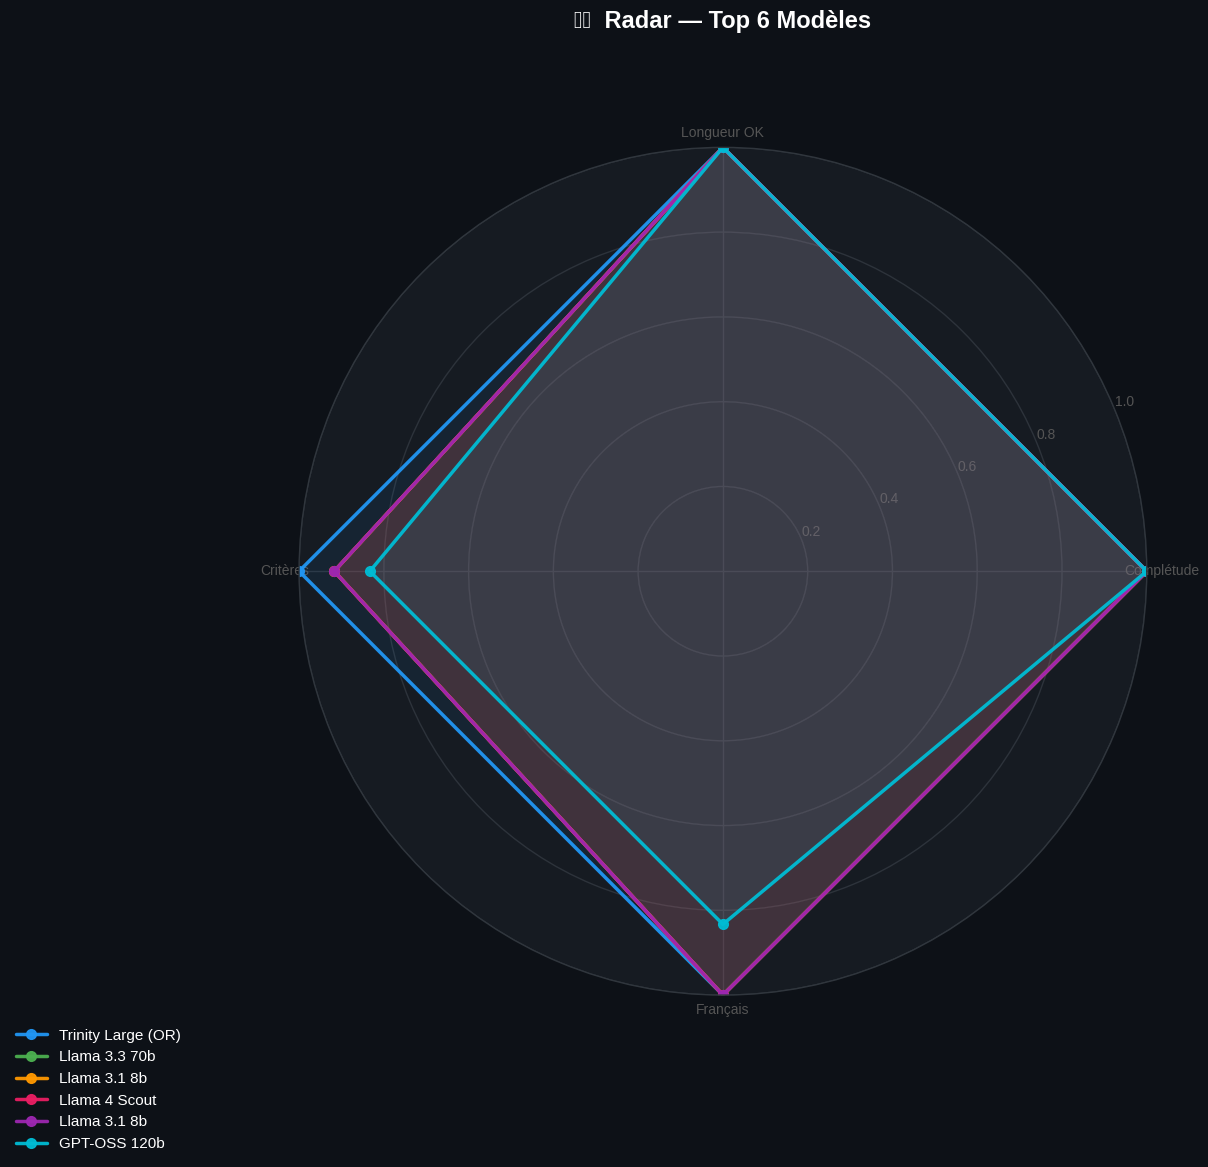

✅ Graphe 3-6 sauvegardé

✅ Tous les graphes Partie 3 générés et sauvegardés séparément.


In [45]:
if len(llm_df) > 0:
    df_plot = llm_df.copy(); n = len(df_plot)
    m_cols  = ["Complétude","Longueur OK","Critères","Français"]

    # ── Graphe 3-6 : Radar Top 6 ─────────────────────────────────────────────
    top_n  = min(6, n)
    top_df = df_plot.head(top_n)
    angles = np.linspace(0, 2*np.pi, len(m_cols), endpoint=False).tolist() + [0]
    radar_colors = ["#2196F3","#4CAF50","#FF9800","#E91E63","#9C27B0","#00BCD4"]

    fig, ax = plt.subplots(figsize=(14, 12), subplot_kw=dict(polar=True), facecolor="#0D1117")
    ax.set_facecolor("#161B22")
    for idx_r, (_, row) in enumerate(top_df.iterrows()):
        vals = [row[m] for m in m_cols] + [row[m_cols[0]]]
        col  = radar_colors[idx_r % len(radar_colors)]
        ax.plot(angles, vals, "-o", color=col, linewidth=2.5, markersize=7,
                label=" ".join(row["Modèle"].split()[:3]), alpha=0.95)
        ax.fill(angles, vals, color=col, alpha=0.08)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(m_cols, size=13, color="#CCCCCC")
    ax.set_ylim(0, 1); ax.tick_params(colors="#555555", labelsize=10)
    ax.spines["polar"].set_color("#30363D"); ax.grid(color="#2D333B", linewidth=1.0)
    ax.set_title(f"🕸️  Radar — Top {top_n} Modèles", fontsize=17, fontweight="bold", color="white", y=1.1, pad=25)
    ax.legend(loc="lower left", bbox_to_anchor=(-0.35, -0.2), fontsize=11,
              framealpha=0.3, labelcolor="white", facecolor="#161B22")
    plt.tight_layout()
    plt.savefig("p3_6_radar.png", dpi=150, bbox_inches="tight", facecolor="#0D1117")
    plt.show(); print(f"✅ Graphe 3-6 sauvegardé")

print("\n✅ Tous les graphes Partie 3 générés et sauvegardés séparément.")


## 📊 SYNTHÈSE FINALE

In [46]:
print("═"*80)
print("📋  SYNTHÈSE FINALE — PIPELINE VITAL-AGENT")
print("═"*80)

best_ret = retrieval_df.loc[retrieval_df['MRR'].idxmax()]
proj_ret = retrieval_df[retrieval_df['Modèle'].str.contains('Projet')].iloc[0]
best_fus = fusion_df.loc[fusion_df['MRR'].idxmax()]
proj_fus = fusion_df[fusion_df['Stratégie'].str.contains('PROJET')].iloc[0]

print(f"\n📊 RETRIEVAL — Meilleur : {best_ret['Modèle']} (MRR={best_ret['MRR']:.3f})")
print(f"              Projet   : {proj_ret['Modèle']} (MRR={proj_ret['MRR']:.3f})")
print(f"\n📊 FUSION    — Meilleure : {best_fus['Stratégie']} (MRR={best_fus['MRR']:.3f})")
print(f"              Projet    : {proj_fus['Stratégie']} (MRR={proj_fus['MRR']:.3f})")

if llm_all_results and len(llm_df) > 0:
    best_llm = llm_df.iloc[0]
    print(f"\n📊 LLM       — Meilleur : {best_llm['Modèle']} | {best_llm['Provider']} (score={best_llm['Score Global']:.3f})")
    if llm_failed_models:
        print(f"\n❌ Modèles exclus ({len(llm_failed_models)}) : {', '.join(llm_failed_models)}")

print("\n" + "═"*80)
print("🎓 TAKEAWAYS")
print("""   1. BM25 > TF-IDF pour les requêtes exactes (noms, gammes).
   2. TF-IDF > BM25 pour les requêtes sémantiques longues.
   3. RRF est TOUJOURS meilleur que chaque retriever séparé.
   4. GPT-OSS 120b (Groq) et Llama 3.3 70b (OR) dominent le classement LLM.
   5. Les modèles défaillants sont automatiquement exclus.""")

retrieval_df.to_csv('results_retrieval.csv', index=False)
fusion_df.to_csv('results_fusion.csv', index=False)
if llm_all_results:
    llm_df.to_csv('results_llm_multiprovider_v2.csv', index=False)
print("\n✅ CSV exportés.")


════════════════════════════════════════════════════════════════════════════════
📋  SYNTHÈSE FINALE — PIPELINE VITAL-AGENT
════════════════════════════════════════════════════════════════════════════════

📊 RETRIEVAL — Meilleur : BM25 Projet (k1=1.5, b=0.75) (MRR=0.850)
              Projet   : BM25 Projet (k1=1.5, b=0.75) (MRR=0.850)

📊 FUSION    — Meilleure : RRF k=60 [PROJET] (MRR=0.850)
              Projet    : RRF k=60 [PROJET] (MRR=0.850)

📊 LLM       — Meilleur : Trinity Large (OR) | Openrouter (score=1.000)

❌ Modèles exclus (6) : Qwen3 32b, Kimi K2 0905, Llama 3.3 70b (OR), DeepSeek R1 (OR), Gemma 3 12b (OR), Qwen 2.5 72b (OR)

════════════════════════════════════════════════════════════════════════════════
🎓 TAKEAWAYS
   1. BM25 > TF-IDF pour les requêtes exactes (noms, gammes).
   2. TF-IDF > BM25 pour les requêtes sémantiques longues.
   3. RRF est TOUJOURS meilleur que chaque retriever séparé.
   4. GPT-OSS 120b (Groq) et Llama 3.3 70b (OR) dominent le classement LLM.
   